In [1]:
import pandas as pd
import matplotlib.pyplot as plt

partidas = [
    {"jugador": "Carlos", "personaje": "Mortaccio", "minutos": 18, "enemigos": 4823, "victoria": True},
    {"jugador": "María", "personaje": "Imelda", "minutos": 12, "enemigos": 2100, "victoria": False},
    {"jugador": "Luis", "personaje": "Clerici", "minutos": 25, "enemigos": 7654, "victoria": True},
    {"jugador": "Ana", "personaje": "Mortaccio", "minutos": 8, "enemigos": 1200, "victoria": False},
    {"jugador": "Carlos", "personaje": "Clerici", "minutos": 30, "enemigos": 9100, "victoria": True},
    {"jugador": "María", "personaje": "Mortaccio", "minutos": 20, "enemigos": 5200, "victoria": True},
    {"jugador": "Ana", "personaje": "Clerici", "minutos": 15, "enemigos": 3800, "victoria": False},
    {"jugador": "Luis", "personaje": "Imelda", "minutos": 10, "enemigos": 1900, "victoria": False}
]

df = pd.DataFrame(partidas)
print(df)

  jugador  personaje  minutos  enemigos  victoria
0  Carlos  Mortaccio       18      4823      True
1   María     Imelda       12      2100     False
2    Luis    Clerici       25      7654      True
3     Ana  Mortaccio        8      1200     False
4  Carlos    Clerici       30      9100      True
5   María  Mortaccio       20      5200      True
6     Ana    Clerici       15      3800     False
7    Luis     Imelda       10      1900     False


In [2]:
# Agrupamos por personaje
resumen = df.groupby("personaje").agg(
    partidas_jugadas=("victoria", "count"),
    victorias=("victoria", "sum"),
    promedio_minutos=("minutos", "mean"),
    promedio_enemigos=("enemigos", "mean")
).round(1)

resumen["win_rate"] = (resumen["victorias"] / resumen["partidas_jugadas"] * 100).round(1)

print(resumen)

           partidas_jugadas  victorias  promedio_minutos  promedio_enemigos  \
personaje                                                                     
Clerici                   3          2              23.3             6851.3   
Imelda                    2          0              11.0             2000.0   
Mortaccio                 3          2              15.3             3741.0   

           win_rate  
personaje            
Clerici        66.7  
Imelda          0.0  
Mortaccio      66.7  


In [3]:
print(resumen[["promedio_minutos", "promedio_enemigos", "win_rate"]])

           promedio_minutos  promedio_enemigos  win_rate
personaje                                               
Clerici                23.3             6851.3      66.7
Imelda                 11.0             2000.0       0.0
Mortaccio              15.3             3741.0      66.7


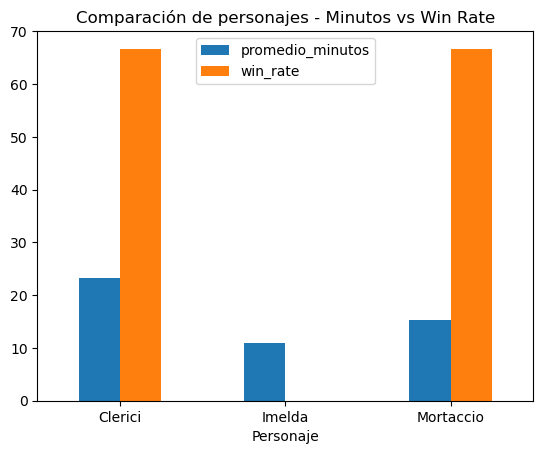

In [4]:
resumen[["promedio_minutos", "win_rate"]].plot(kind="bar")
plt.title("Comparación de personajes - Minutos vs Win Rate")
plt.xlabel("Personaje")
plt.xticks(rotation=0)
plt.show()

Mirando la gráfica aparentemente Clerici y Mortaccio serían los personajes a recomendar para ser utilizados por tener el mayor win rate. Pero en lo personal al mirar el promedio de minutos Clerici tuvo partidas en promedio más extensas, por lo tanto, se intuye que esta obteniendo más oro y más logros dentro del videojuego, se sugiere explorar si es posible obtener esos datos para tener una conclusión más afinada.